In [1]:
# Main Linear Regression implementation
import numpy as np


class LinearRegression:
    def __init__(
        self,
        learning_rate=0.01,
        n_iterations=1000,
        batch_size=None,          
        l2_lambda=0.0,            
        early_stopping=False,
        tol=1e-6,
        scale=True,
        verbose=False,
        random_state=42,
    ):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.batch_size = batch_size
        self.l2_lambda = l2_lambda
        self.early_stopping = early_stopping
        self.tol = tol
        self.scale = scale
        self.verbose = verbose
        self.random_state = random_state

        self.weights = None
        self.bias = None
        self.cost_history = []
        self.X_mean = None
        self.X_std = None


    def _validate_inputs(self, X, y=None):
        X = np.array(X, dtype=float)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        if y is not None:
            y = np.array(y, dtype=float)
            if len(X) != len(y):
                raise ValueError("X and y must have same length")
            return X, y

        return X

    def _scale_features(self, X, training=False):
        if not self.scale:
            return X

        if training:
            self.X_mean = X.mean(axis=0)
            self.X_std = X.std(axis=0)
            self.X_std[self.X_std == 0] = 1

        return (X - self.X_mean) / self.X_std


    def _compute_cost(self, y_true, y_pred):
        n = len(y_true)
        mse = (1 / (2 * n)) * np.sum((y_pred - y_true) ** 2)

        # L2 regularization
        if self.l2_lambda > 0:
            mse += (self.l2_lambda / (2 * n)) * np.sum(self.weights ** 2)

        return mse


    def fit(self, X, y):
        np.random.seed(self.random_state)

        X, y = self._validate_inputs(X, y)
        X = self._scale_features(X, training=True)

        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.cost_history = []

        batch_size = self.batch_size or n_samples
        prev_cost = float("inf")

        for epoch in range(self.n_iterations):

            indices = np.random.permutation(n_samples)
            X_shuffled = X[indices]
            y_shuffled = y[indices]


            for start in range(0, n_samples, batch_size):
                end = start + batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]

                y_pred = np.dot(X_batch, self.weights) + self.bias
                error = y_pred - y_batch
                m = len(y_batch)

                dw = (1 / m) * np.dot(X_batch.T, error)
                db = (1 / m) * np.sum(error)

                if self.l2_lambda > 0:
                    dw += (self.l2_lambda / m) * self.weights

                self.weights -= self.lr * dw
                self.bias -= self.lr * db

            y_full_pred = np.dot(X, self.weights) + self.bias
            cost = self._compute_cost(y, y_full_pred)
            self.cost_history.append(cost)

            if self.verbose and epoch % 100 == 0:
                print(f"Epoch {epoch}, Cost: {cost:.6f}")

            if self.early_stopping and abs(prev_cost - cost) < self.tol:
                if self.verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

            prev_cost = cost

        return self




    def predict(self, X):
        if self.weights is None:
            raise ValueError("Model is not trained yet.")

        X = self._validate_inputs(X)
        X = self._scale_features(X, training=False)

        return np.dot(X, self.weights) + self.bias


    def mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    def r2_score(self, y_true, y_pred):
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return 1 - (ss_res / ss_tot)


Epoch 0, Cost: 22.605568
Epoch 100, Cost: 0.404071
Epoch 200, Cost: 0.403292
Epoch 300, Cost: 0.403292
Epoch 400, Cost: 0.403292
Epoch 500, Cost: 0.403292
Epoch 600, Cost: 0.403292
Epoch 700, Cost: 0.403292
Epoch 800, Cost: 0.403292
Epoch 900, Cost: 0.403292
MSE: 0.8065845639670531
R^2: 0.7692735413614223


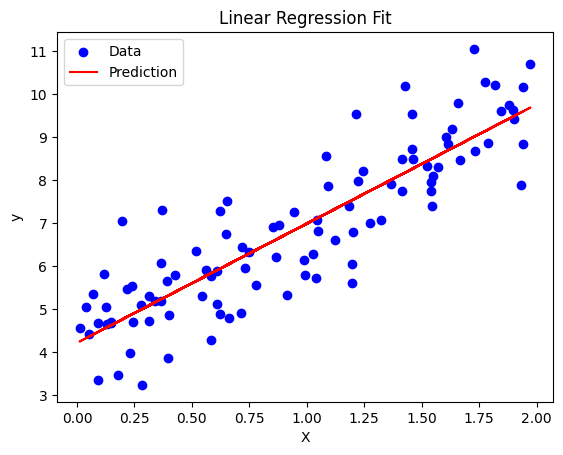

In [2]:
# Test the LinearRegression implementation
import matplotlib.pyplot as plt

# Generate synthetic data
def make_data(n=100, noise=1.0, random_state=42):
    np.random.seed(random_state)
    X = 2 * np.random.rand(n, 1)
    y = 4 + 3 * X[:, 0] + np.random.randn(n) * noise
    return X, y

X, y = make_data()

# Initialize and fit the model
model = LinearRegression(learning_rate=0.05, n_iterations=1000, verbose=True)
model.fit(X, y)
y_pred = model.predict(X)

# Print metrics
print("MSE:", model.mse(y, y_pred))
print("R^2:", model.r2_score(y, y_pred))

# Plot results
plt.scatter(X, y, color="blue", label="Data")
plt.plot(X, y_pred, color="red", label="Prediction")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Fit")
plt.legend()
plt.show()
